### [K線捕手](https://www.facebook.com/kevinyang20180801)  

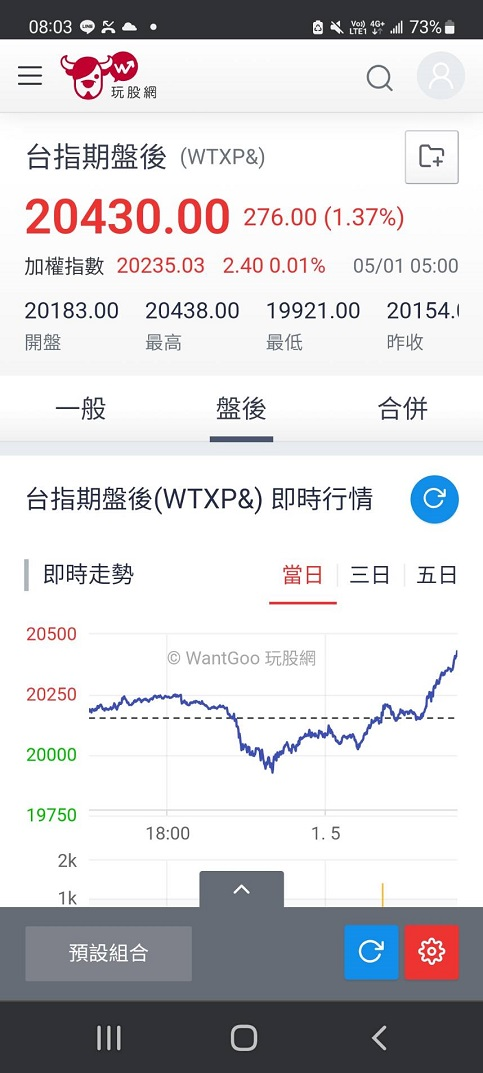  

### 本日進度  
* 量化技術分析系統：規劃與開發  
  - 驗證型態識別方法  

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [2]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [3]:
# 型態視覺化：型態後處理程序之雛形
def patterns_visualization( prices, patterns) :
    for pattern_name in patterns:
        # 顯示型態名稱
        print('＃＃＃ {} ＃＃＃'.format(pattern_name))
        for pattern in patterns[pattern_name] :
            
            # 顯示型態轉折點參數
            print('☆ 轉折點參數 ＝ {} \n★ 型態資訊 ＝ \n {} '.format(pattern['argument'],pattern['window']))
            
            # 視覺化型態
            pattern_window = pattern['window']
            
            # 驗證：型態最後一個轉折點離價格資料距離
            print('◆ 型態最後一個轉折點離價格資料距離 ＝ {} '.format( date_to_index(prices,prices.iloc[-1].name) - date_to_index(prices,pattern_window.iloc[-1]['Date']) ))
            
            seq_of_seq_of_points = []
            if pattern_name == '雙重頂' or pattern_name == '雙重底':
                pattern_first_date_idx  = pattern_window.iloc[0].name
                pattern_start_date_idx  = pattern_window.iloc[1].name
                neckline_start_date_idx = pattern_start_date_idx - ((pattern_start_date_idx - pattern_first_date_idx) // 2) 
                neckline_end_date_idx   = ((pattern_start_date_idx - pattern_first_date_idx) // 2) + pattern_window.iloc[-1].name
                neckline_end_date_idx   = neckline_end_date_idx if neckline_end_date_idx < prices.shape[0] else pattern_window.iloc[-1].name
            
                neckline_start_date  = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
                neckline_end_date    = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
                neckline_start_price = pattern_window.iloc[2]['Price']
                neckline_end_price   = pattern_window.iloc[2]['Price']
        
                # 設定頸線
                seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
            elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
                pattern_first_date_idx  = pattern_window.iloc[0].name
                pattern_start_date_idx  = pattern_window.iloc[1].name
                neckline_start_date_idx = pattern_start_date_idx - ((pattern_start_date_idx - pattern_first_date_idx) // 2) 
                neckline_end_date_idx   = ((pattern_start_date_idx - pattern_first_date_idx) // 2) + pattern_window.iloc[-1].name
                neckline_end_date_idx   = neckline_end_date_idx if neckline_end_date_idx < prices.shape[0] else pattern_window.iloc[-1].name
        
                neckline_start_date = prices.iloc[neckline_start_date_idx].name.strftime("%Y-%m-%d")
                neckline_end_date   = prices.iloc[neckline_end_date_idx].name.strftime("%Y-%m-%d")
                neckline_x = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                neckline_y = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
                neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                neckline_start_price = neckline_slope * date_to_index(prices,neckline_start_date) + neckline_intercept
                neckline_end_price   = neckline_slope * date_to_index(prices,neckline_end_date) + neckline_intercept
                
                # 設定頸線
                seq_of_seq_of_points=[[(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]
            elif pattern_name == '矩形' :
                # NOTE : 後處理
                rect_upper_edge =  max(pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price'])
                rect_lower_edge =  min(pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price'])

                line1_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_start_price = rect_upper_edge
                line1_end_price   = rect_upper_edge

                line2_start_date  = line1_start_date
                line2_end_date    = line1_end_date
                line2_start_price = rect_lower_edge
                line2_end_price   = rect_lower_edge
                
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            elif pattern_name == '三角形' : 
                line1_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[0]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                line1_y = [pattern_window.iloc[0]['Price'],pattern_window.iloc[4]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
                
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line2_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
                
                # 後處理：無效三角形判斷 — 交叉
                if line2_end_price > line1_end_price :
                    print("  Ⅹ 無效的三角形型態")
                    continue
                else :
                    # 設定趨勢線
                    seq_of_seq_of_points=[
                        [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                        [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                    ]
            elif pattern_name == '上升旗形' or pattern_name == '下降旗形' or pattern_name == '看跌三角旗形' or pattern_name == '看漲三角旗形'  : 
                line1_start_date = pattern_window.iloc[1]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line1_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
            
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                line2_y = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
            
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            else :
                line1_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
                line1_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
                line1_x = [date_to_index(prices,pattern_window.iloc[0]['Date']),date_to_index(prices,pattern_window.iloc[2]['Date'])]
                line1_y = [pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price']]
                line1_slope,line1_intercept = np.polyfit(line1_x,line1_y,1)
                line1_start_price = line1_slope * date_to_index(prices,line1_start_date) + line1_intercept
                line1_end_price   = line1_slope * date_to_index(prices,line1_end_date) + line1_intercept
            
                line2_start_date = line1_start_date
                line2_end_date = line1_end_date
                line2_x = [date_to_index(prices,pattern_window.iloc[1]['Date']),date_to_index(prices,pattern_window.iloc[3]['Date'])]
                line2_y = [pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']]
                line2_slope,line2_intercept = np.polyfit(line2_x,line2_y,1)
                line2_start_price = line2_slope * date_to_index(prices,line2_start_date) + line2_intercept
                line2_end_price   = line2_slope * date_to_index(prices,line2_end_date) + line2_intercept
            
                # 設定趨勢線
                seq_of_seq_of_points=[
                    [(line1_start_date,line1_start_price),(line1_end_date,line1_end_price)],
                    [(line2_start_date,line2_start_price),(line2_end_date,line2_end_price)],
                ]
            
            # 設定K線格式
            mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
            s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
            
            # 設定轉折點
            turning_points_len = len(np.array(prices['Close']))
            turning_points = np.array([np.nan]*turning_points_len)
            for point in pattern_window.iterrows() :
                turning_points[point[0]] = point[1]['Price']
            apds = [mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=25,color='xkcd:sky blue')]
            
            # 繪製K線圖
            kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, addplot=apds, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
            mpf.plot(prices,**kwargs)

In [4]:
def normalization(data) :
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range

In [5]:
# 型態視覺化：型態後處理程序之雛形
def gpt4o_patterns_visualization(prices,patterns) :
    if type(patterns) is list :
        for pattern in patterns :
            print('型態類型 ＝ {} ， 型態開始日期 ＝ {} ， 型態結束日期 ＝ {} '.format(pattern['type'],pattern['start'],pattern['end']))
            range_price = prices[pattern['start']:pattern['end']]
            if pattern['type'] == '頭肩頂' or pattern['type'] == '雙頂' or pattern['type'] == '圓弧頂' :
                # 使用自動趨勢線繪製頸線
                chart_pattern        = myutils.StockChartPatterns(range_price,debug=True)
                params,lines         = chart_pattern.TrendlineAutomation(mode='open_close')
                # 將趨勢線進行正規化，求頸線真正的角度
                # 趨勢線價格正規化
                line_prices_list = []
                line_prices_list.append(lines[0][0][1])
                line_prices_list.append(lines[0][1][1])
                line_prices_list.append(lines[1][0][1])
                line_prices_list.append(lines[1][1][1])
                line_prices      = np.array(line_prices_list)
                line_prices_norm = normalization(line_prices)
                ## 求斜率並轉換成角度
                line1_x      = [0.0, 1.0]
                line1_y      = [line_prices_norm[0],line_prices_norm[1]]
                line2_x      = [0.0, 1.0]
                line2_y      = [line_prices_norm[2],line_prices_norm[3]]
                line1_angle  = np.rad2deg(np.arctan2(line1_y[1] - line1_y[0] , line1_x[1] - line1_x[0]))
                line2_angle  = np.rad2deg(np.arctan2(line2_y[1] - line2_y[0] , line2_x[1] - line2_x[0]))
                neckline_angle = abs(line1_angle)
                if neckline_angle > 15.0 :
                    lowest_point = sys.float_info.max
                    for index,price in range_price.iterrows() :
                        if price['Open'] < lowest_point :
                            lowest_point = price['Open']
                        if price['Close'] < lowest_point :
                            lowest_point = price['Close']
                    seq_of_seq_of_points = [(lines[0][0][0],lowest_point),(lines[0][1][0],lowest_point)]
                else :
                    seq_of_seq_of_points = lines[0]
                # 設定K線格式
                mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
                s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
                # 繪製K線圖
                kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
                mpf.plot(prices,**kwargs)
            else :
                # TODO : 待確認與實作
                pass
    else :
        # 回傳值不符合要求，列印出來以做確認
        print(patterns)

In [6]:
# 型態視覺化：型態後處理程序之雛形
def bottom_pattern_visualization( prices, bottom_pattern) :
    bottom_pattern_breakout = False
    if 'bottom_pattern_breakout_date' in bottom_pattern :
        bottom_pattern_breakout_date  = bottom_pattern['bottom_pattern_breakout_date']
        bottom_pattern_breakout_price = bottom_pattern['bottom_pattern_breakout_price']
        bottom_pattern_breakout = True
    neckline_start_date  = bottom_pattern['neckline_start_date']
    neckline_start_price = bottom_pattern['neckline_start_price']
    neckline_end_date    = bottom_pattern['neckline_end_date']
    neckline_end_price   = bottom_pattern['neckline_end_price']
    bottom_price_date    = bottom_pattern['bottom_price_date']
    bottom_price         = bottom_pattern['bottom_price']
    on_neckline_price    = bottom_pattern['on_neckline_price']
    target_price         = bottom_pattern['target_price']
    
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

    # 設定頸線
    if bottom_pattern_breakout is True :
        seq_of_seq_of_points=[
            [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
            [(bottom_price_date,bottom_price),(bottom_price_date,on_neckline_price)],
            [(bottom_pattern_breakout_date,bottom_pattern_breakout_price),(bottom_pattern_breakout_date,target_price)]
                             ]
    else :
        seq_of_seq_of_points=[
            [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
            [(bottom_price_date,bottom_price),(bottom_price_date,on_neckline_price)],
            [(neckline_end_date,neckline_end_price),(neckline_end_date,target_price)]
                             ]
    
    # 繪製K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, alines=dict(alines=seq_of_seq_of_points, linewidths=(1.2,10,10), colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
    mpf.plot(prices,**kwargs)

In [7]:
import datetime

# 雛型版
def chart_pattern_recognition( prices):
    # 型態回傳字典
    pattern_return_list = []
    
    # 建立「股票技術型態識別」物件
    chart_pattern = myutils.StockChartPatterns(prices,debug=True)
    
    # 底型反轉操作法之底部型態
    turning_point_args = []
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
    turning_point_args.append({'mode':'open_close', 'order':5})
    patterns = chart_pattern.RecognitionBottom(turning_point_args=turning_point_args)
    if patterns is not None and len(patterns) > 0 :
        print('底型反轉操作法之底部型態 ＝ {}'.format(patterns))
        # 只保留最後一個底部型態
        bottom_pattern = patterns[-1]['bottom_pattern']
        if date_to_index(prices,bottom_pattern['neckline_end_date']) > (date_to_index(prices,prices.iloc[-1].name) / 2) :
            pattern_return_list.append({'類型' : '底型反轉', '型態' : '底部型態', '資料' : bottom_pattern })
        else :
            print('找到的底部型態太靠前 ： 頸線結束日期 ＝ {} （索引 ＝ {}）， 價格資料的最後一個索引 ＝ {} '.format(bottom_pattern['neckline_end_date'],date_to_index(prices,bottom_pattern['neckline_end_date']),date_to_index(prices,pattern_window.iloc[-1]['Date'])))
 
    # GPT-4o版之主要型態
    gpt4o_major_pattern_type_char = '＊'
    gpt4o_major_pattern_start_idx = -1
    gpt4o_major_pattern_end_idx   = -1
    patterns = chart_pattern.RecognitionUsingGPT4o()
    if patterns is not None and type(patterns) is list :
        print('GPT-4o版之主要型態 ＝ {}'.format(patterns))
        pattern            = patterns[0]
        pattern_start_date = pattern['start']
        pattern_end_date   = pattern['end']
        if pattern_start_date not in prices.index or pattern_end_date not in prices.index :
            # TODO : 調整程序仍待改善
            print('主要型態的開始或結束日期不在價格內，進行日期校正')
            while True :
                if pattern_start_date in prices.index :
                    break
                else :
                    start_date         = datetime.datetime.strptime(pattern_start_date, '%Y-%m-%d')
                    pattern_start_date = (start_date + datetime.timedelta(days=1)).strftime('%Y-%m-%d')
            while True :
                if pattern_end_date in prices.index :
                    break
                else :
                    end_date         = datetime.datetime.strptime(pattern_end_date, '%Y-%m-%d')
                    pattern_end_date = (end_date - datetime.timedelta(days=1)).strftime('%Y-%m-%d')
            print('日期校正結果 ： 開始 ＝ {} ， 結束 ＝ {}'.format(pattern_start_date,pattern_end_date))
        gpt4o_major_pattern_start_idx = date_to_index(prices,pattern_start_date)
        gpt4o_major_pattern_end_idx   = date_to_index(prices,pattern_end_date)
        if gpt4o_major_pattern_end_idx > (date_to_index(prices,prices.iloc[-1].name) / 2) :
            if '頂' in pattern['type'] :
                gpt4o_major_pattern_type_char = '頂'
            elif '底' in pattern['type'] :
                gpt4o_major_pattern_type_char = '底'
        else :
            print('找到的主要型態太靠前 ： 型態結束日期索引 ＝ {} （索引 ＝ {}） ， 價格資料的最後一個索引 ＝ {} '.format(pattern['end'],gpt4o_major_pattern_end_idx,date_to_index(prices,pattern_window.iloc[-1]['Date'])))
            gpt4o_major_pattern_start_idx = -1
            gpt4o_major_pattern_end_idx   = -1
    
    # 進行型態識別
    turning_point_args = []
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
    turning_point_args.append({'mode':'open_close', 'order':5})
    turning_point_args.append({'mode':'open_close', 'order':10})
    turning_point_args.append({'mode':'open_close', 'order':15})
    turning_point_args.append({'mode':'open_close', 'order':20})
    turning_point_args.append({'mode':'open_close', 'order':25})
    turning_point_args.append({'mode':'open_close', 'order':30})
    patterns = chart_pattern.Recognition(max_bars=360, turning_point_args=turning_point_args)
    if patterns is not None and len(patterns) > 0 :
        if gpt4o_major_pattern_type_char == '頂' or gpt4o_major_pattern_type_char == '底' :
            # 與GPT-4o主要型態相符之距離
            major_pattern_distance = sys.maxsize
            # 候選型態
            candidate_pattern      = None
            # 過濾找到的型態，對照GPT-4o版之主要型態
            # TODO : 程序仍待檢討
            for pattern_name in patterns:
                if gpt4o_major_pattern_type_char in pattern_name :
                    for pattern in patterns[pattern_name] :
                        window            = pattern['window']
                        pattern_start_idx = window.iloc[1].name
                        pattern_end_idx   = window.iloc[-1].name
                        pattern_distance  = abs(gpt4o_major_pattern_start_idx - pattern_start_idx) + abs(gpt4o_major_pattern_end_idx - pattern_end_idx)
                        if pattern_distance < major_pattern_distance :
                            print('pattern_name = {} , gpt4o_major_pattern_start_idx = {} , gpt4o_major_pattern_end_idx = {} , pattern_start_idx = {} , pattern_end_idx = {} '.format(pattern_name,gpt4o_major_pattern_start_idx,gpt4o_major_pattern_end_idx,pattern_start_idx,pattern_end_idx))
                            major_pattern_distance = pattern_distance
                            candidate_pattern         = [pattern_name,pattern['argument'],pattern['window']]
            if candidate_pattern is not None :
                neckline_start_date  = None
                neckline_end_date    = None
                neckline_start_price = None
                neckline_end_price   = None
                # 設定頸線開始與結束索引
                pattern_name   = candidate_pattern[0]
                pattern_window = candidate_pattern[2]
                if pattern_name == '雙重頂' or pattern_name == '雙重底':
                    pattern_first_date_idx  = pattern_window.iloc[0].name
                    pattern_start_date_idx  = pattern_window.iloc[1].name
                    pattern_end_date_idx    = pattern_window.iloc[-1].name
                    neckline_price          = pattern_window.iloc[2]['Price']
                    for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                        if '頂' in pattern_name :
                            if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                                neckline_start_date  = prices.iloc[idx].name
                                neckline_start_price = neckline_price
                                break
                        elif '底' in pattern_name :
                            if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                                neckline_start_date  = prices.iloc[idx].name
                                neckline_start_price = neckline_price
                                break
                    for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                        if '頂' in pattern_name :
                            if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                                neckline_end_date  = prices.iloc[idx].name
                                neckline_end_price = neckline_price
                                break
                        elif '底' in pattern_name :
                            if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                                neckline_end_date  = prices.iloc[idx].name
                                neckline_end_price = neckline_price
                                break
                    if neckline_end_date is None or neckline_end_price is None :
                        # 型態進行中
                        neckline_end_date  = prices.iloc[-1].name
                        neckline_end_price = neckline_price
                elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
                    pattern_first_date_idx  = pattern_window.iloc[0].name
                    pattern_start_date_idx  = pattern_window.iloc[1].name
                    pattern_end_date_idx    = pattern_window.iloc[-1].name
                    
                    neckline_x = [date_to_index(prices,pattern_window.iloc[2]['Date']),date_to_index(prices,pattern_window.iloc[4]['Date'])]
                    neckline_y = [pattern_window.iloc[2]['Price'],pattern_window.iloc[4]['Price']]
                    neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                    
                    for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                        on_nickline_price = neckline_slope * idx + neckline_intercept
                        if '頂' in pattern_name :
                            if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                                neckline_start_date  = prices.iloc[idx].name
                                neckline_start_price = on_nickline_price
                                break
                        elif '底' in pattern_name :
                            if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                                neckline_start_date  = prices.iloc[idx].name
                                neckline_start_price = on_nickline_price
                                break
                    for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                        on_nickline_price = neckline_slope * idx + neckline_intercept
                        if '頂' in pattern_name :
                            if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                                neckline_end_date  = prices.iloc[idx].name
                                neckline_end_price = on_nickline_price
                                break
                        elif '底' in pattern_name :
                            if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                                neckline_end_date  = prices.iloc[idx].name
                                neckline_end_price = on_nickline_price
                                break
                    if neckline_end_date is None or neckline_end_price is None :
                        # 型態進行中
                        neckline_end_date  = prices.iloc[-1].name
                        neckline_end_price = neckline_slope * date_to_index(prices,prices.iloc[-1].name) + neckline_intercept
                # 確認頸線是否存在
                if neckline_start_date is None or neckline_end_date is None or neckline_start_price is None or neckline_end_price is None :
                    print('找不到頸線？')
                else :
                    pattern_return_dict = {'neckline_start_date':neckline_start_date,'neckline_end_date':neckline_end_date,'neckline_start_price':neckline_start_price,'neckline_end_price':neckline_end_price,'window':pattern_window}
                    pattern_return_list.append({'類型' : '反轉型態', '型態' : candidate_pattern[0], '資料' : pattern_return_dict})
        else :
            # TODO : 還不知道怎麼處理
            pass
    
    return pattern_return_list

In [8]:
# 雛型版
def chart_pattern_visualization(prices,recognition_patterns) :
    
    seq_of_seq_of_points = []
    apds                 = [] 
    
    for recognition_pattern in recognition_patterns :
        pattern_type = recognition_pattern['類型']
        pattern_name = recognition_pattern['型態']
        pattern      = recognition_pattern['資料']
    
        if pattern_type == '底型反轉' :
            bottom_pattern          = pattern
            bottom_pattern_breakout = False
            if 'bottom_pattern_breakout_date' in bottom_pattern :
                bottom_pattern_breakout_date  = bottom_pattern['bottom_pattern_breakout_date']
                bottom_pattern_breakout_price = bottom_pattern['bottom_pattern_breakout_price']
                bottom_pattern_breakout = True
            neckline_start_date  = bottom_pattern['neckline_start_date']
            neckline_start_price = bottom_pattern['neckline_start_price']
            neckline_end_date    = bottom_pattern['neckline_end_date']
            neckline_end_price   = bottom_pattern['neckline_end_price']
            bottom_price_date    = bottom_pattern['bottom_price_date']
            bottom_price         = bottom_pattern['bottom_price']
            on_neckline_price    = bottom_pattern['on_neckline_price']
            target_price         = bottom_pattern['target_price']
            
            # 設定頸線
            seq_of_seq_of_points.append([(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)])
        elif pattern_type == '反轉型態' :
            pattern_window = pattern['window']
            if pattern_name == '雙重頂' or pattern_name == '雙重底' or pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
                # 設定頸線
                neckline_start_date  = pattern['neckline_start_date']
                neckline_start_price = pattern['neckline_start_price']
                neckline_end_date    = pattern['neckline_end_date']
                neckline_end_price   = pattern['neckline_end_price']
                seq_of_seq_of_points.append([(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)])
                # 設定轉折點
                turning_points_len = len(np.array(prices['Close']))
                turning_points = np.array([np.nan]*turning_points_len)
                for point in pattern_window.iterrows() :
                    turning_points[point[0]] = point[1]['Price']
                apds.append(mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=25,color='xkcd:sky blue'))
    else :
        # 未知
        pass
    
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定參數
    kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True, addplot=apds, alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), datetime_format='%Y-%m-%d', warn_too_much_data=2000)
    # 繪製K線圖
    mpf.plot(prices,**kwargs)

In [9]:
##### 使用2023年8月24日到今日2025年4月30日收盤之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_250430.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

> 個別驗證

In [10]:
# 建立「股票技術型態識別」物件
chart_pattern = myutils.StockChartPatterns(df_k_line)

＃＃＃ 雙重頂 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
45        2023-10-31  16001.27   LO
214       2024-07-11  24390.03   HI
229       2024-08-05  19830.88   LO
279       2024-10-18  23620.57   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 126 


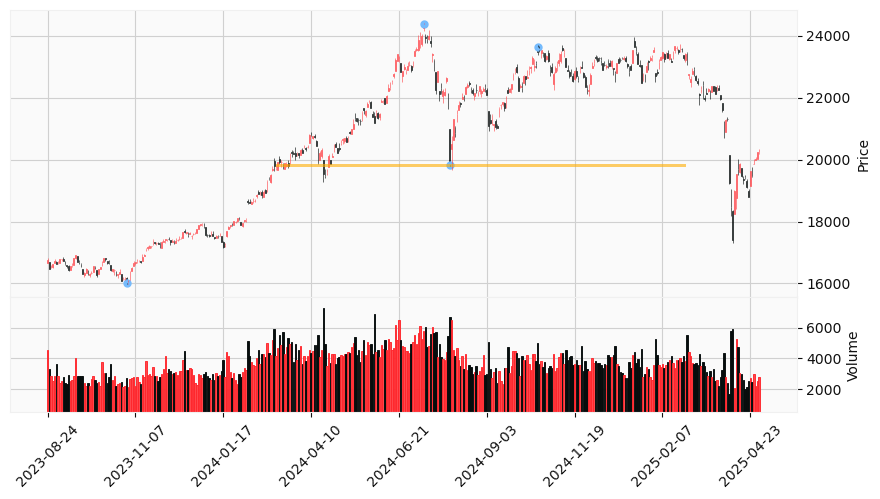

＃＃＃ 上升楔型 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
229       2024-08-05  19830.88   LO
279       2024-10-18  23620.57   HI
308       2024-11-29  22202.28   LO
334       2025-01-07  23824.72   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 71 


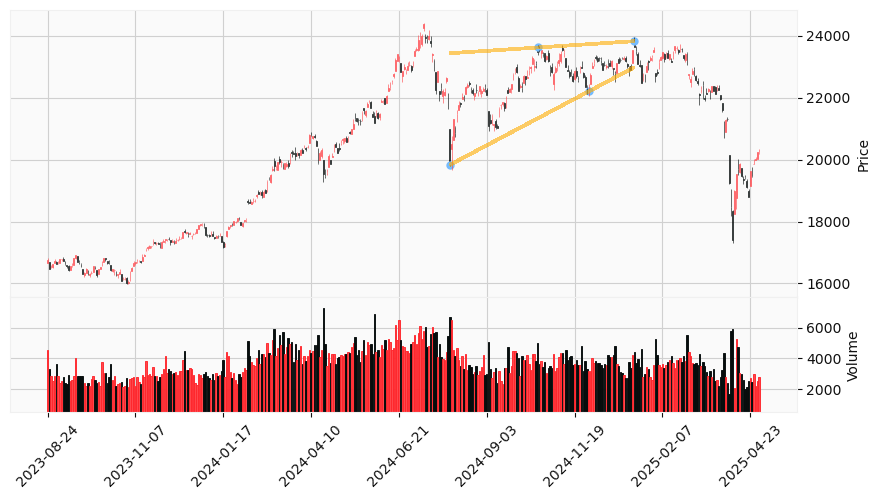

＃＃＃ 矩形 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
279       2024-10-18  23620.57   HI
308       2024-11-29  22202.28   LO
334       2025-01-07  23824.72   HI
338       2025-01-13  22488.33   LO 
◆ 型態最後一個轉折點離價格資料距離 ＝ 67 


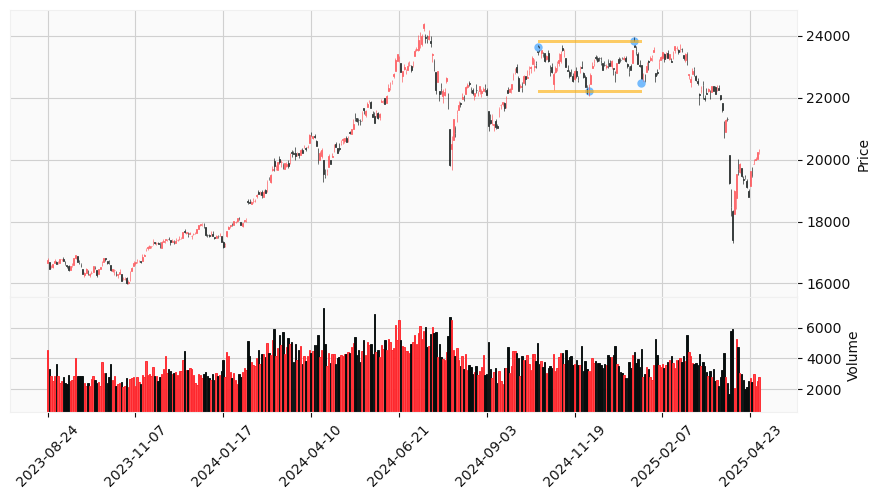

＃＃＃ 看漲三角旗形 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
45        2023-10-31  16001.27   LO
214       2024-07-11  24390.03   HI
229       2024-08-05  19830.88   LO
279       2024-10-18  23620.57   HI
308       2024-11-29  22202.28   LO 
◆ 型態最後一個轉折點離價格資料距離 ＝ 97 


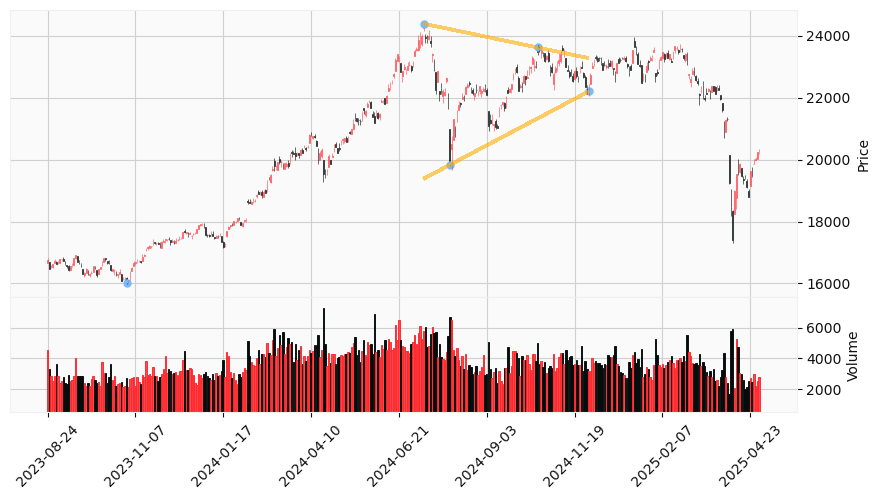

＃＃＃ 三重頂 ＃＃＃
☆ 轉折點參數 ＝ {'mode': 'open_close', 'order': 25} 
★ 型態資訊 ＝ 
                 Date     Price Type
DateIndex                          
229       2024-08-05  19830.88   LO
279       2024-10-18  23620.57   HI
308       2024-11-29  22202.28   LO
334       2025-01-07  23824.72   HI
338       2025-01-13  22488.33   LO
360       2025-02-21  23730.25   HI 
◆ 型態最後一個轉折點離價格資料距離 ＝ 45 


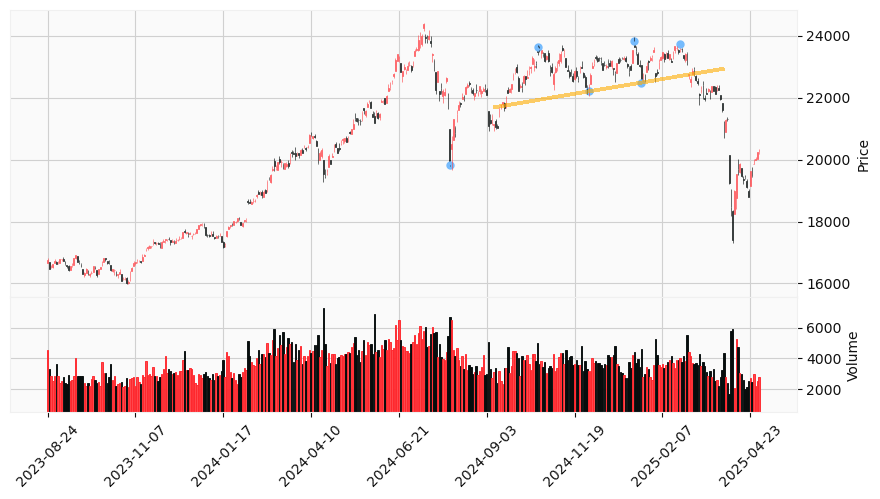

In [11]:
# 進行型態識別
patterns = chart_pattern.Recognition(max_bars = 360,turning_point_args={'mode':'open_close', 'order':25})
patterns_visualization(df_k_line,patterns)

型態類型 ＝ 頭肩頂 ， 型態開始日期 ＝ 2024-04-18 ， 型態結束日期 ＝ 2025-03-20 
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 0），趨勢線結束索引 ＝ 222（價格資料結束索引 ＝ 222）


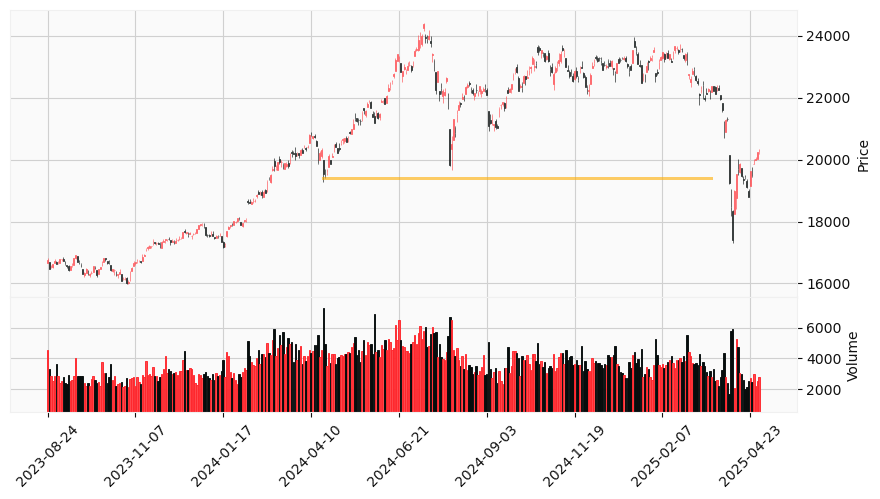

In [12]:
# 進行型態識別(GPT-4o版)
patterns = chart_pattern.RecognitionUsingGPT4o()
gpt4o_patterns_visualization(df_k_line,patterns)

{'neckline_start_date': '2025-04-02', 'neckline_start_price': 19915.44092140465, 'neckline_end_date': '2025-04-30', 'neckline_end_price': 19766.88712350697, 'bottom_price_date': '2025-04-09', 'bottom_price': 17391.76, 'on_neckline_price': 19890.68195508837, 'target_price': 22265.809078595343}


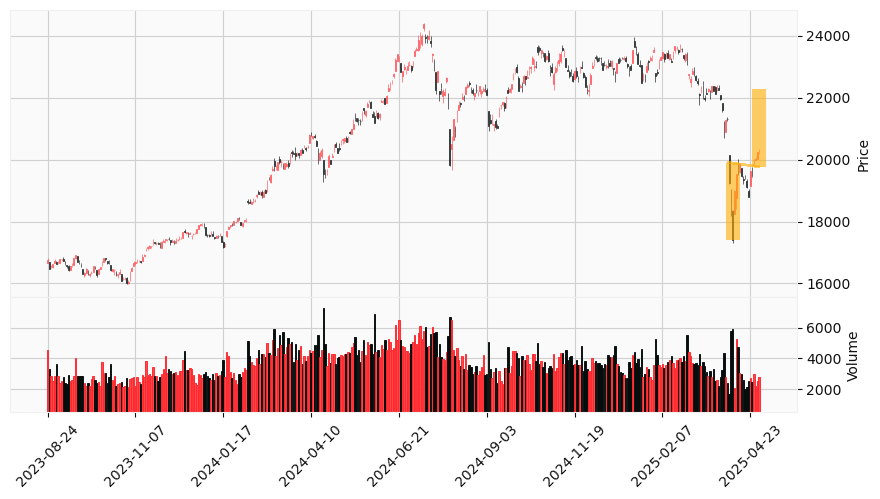

In [13]:
# 進行底部型態識別
patterns = chart_pattern.RecognitionBottom()
pattern = patterns[-1]['bottom_pattern']
print(pattern)
bottom_pattern_visualization(df_k_line,pattern)

> 整合驗證

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 19） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 42） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 390 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 401 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 390），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 401）
ＤＥＢＵＧ ： 頸線角度（絕對值） ＝ 2.08°
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 401 ～ 406
ＤＥＢＵＧ ： 底部最低價格 ＝ 17391.76元 ； 估算目標價 ＝ 22265.81元
底型反轉操作法之底部型態 ＝ [{'argument': {'mode': 'open_close', 'order': 5}, 'bottom_pattern': {'neckline_start_date': '2025-04-02', 'neckline_start_price': 19915.44092140465, 'neckline_end_date': '2025-04-30', 'neckline_end_price': 19766.88712350697, 'bottom_price_date': '2025-04-09', 'bottom_price': 17391.76, 'on_neckline_price': 19890.68195508837, 'target_price': 22265.809078595343}}]
GPT-4o版之主要型態 ＝ [{'type': '頭肩頂', 'start': '2024-04-18', 'end': '2025-03-20'}]
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 

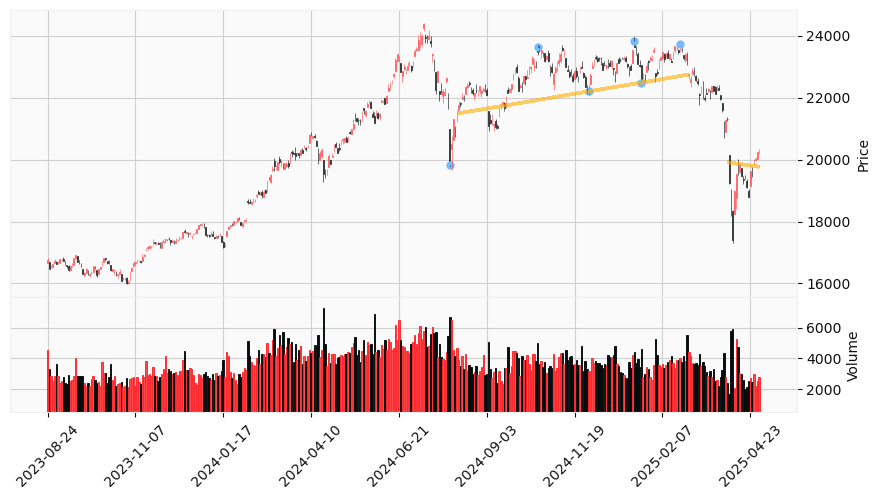

In [14]:
result = chart_pattern_recognition(df_k_line)
chart_pattern_visualization(df_k_line,result)

> 區間驗證

In [15]:
# 設定區間價格(季線條件)
range_prices = df_k_line[df_k_line.iloc[-90].name:]

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 4） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 11） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 74 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 85 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 74），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 85）
ＤＥＢＵＧ ： 頸線角度（絕對值） ＝ 2.08°
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 85 ～ 90
ＤＥＢＵＧ ： 底部最低價格 ＝ 17391.76元 ； 估算目標價 ＝ 22265.81元
底型反轉操作法之底部型態 ＝ [{'argument': {'mode': 'open_close', 'order': 5}, 'bottom_pattern': {'neckline_start_date': '2025-04-02', 'neckline_start_price': 19915.44092140465, 'neckline_end_date': '2025-04-30', 'neckline_end_price': 19766.88712350697, 'bottom_price_date': '2025-04-09', 'bottom_price': 17391.76, 'on_neckline_price': 19890.68195508837, 'target_price': 22265.809078595343}}]
GPT-4o版之主要型態 ＝ [{'type': '頭肩底', 'start': '2025-03-21', 'end': '2025-04-30'}]
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 'open_c

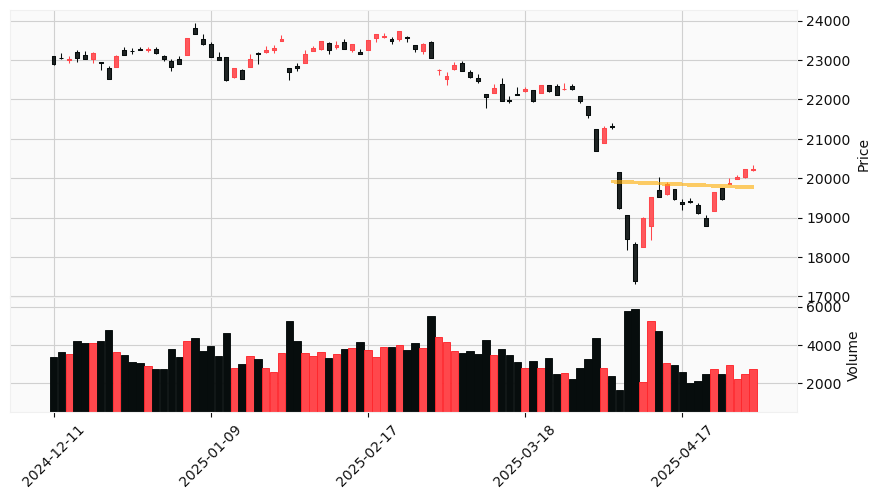

In [16]:
result = chart_pattern_recognition(range_prices)
chart_pattern_visualization(range_prices,result)

In [17]:
# 設定區間價格(年線條件)
range_prices = df_k_line[df_k_line.iloc[-360].name:]

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 15） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 35） 
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 344 （日期 ＝ 2025-04-09 ） ， 底部型態結束索引 ＝ 355 （日期 ＝ 2025-04-24 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 344），趨勢線結束索引 ＝ 11（價格資料結束索引 ＝ 355）
ＤＥＢＵＧ ： 頸線角度（絕對值） ＝ 2.08°
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 355 ～ 360
ＤＥＢＵＧ ： 底部最低價格 ＝ 17391.76元 ； 估算目標價 ＝ 22265.81元
底型反轉操作法之底部型態 ＝ [{'argument': {'mode': 'open_close', 'order': 5}, 'bottom_pattern': {'neckline_start_date': '2025-04-02', 'neckline_start_price': 19915.44092140465, 'neckline_end_date': '2025-04-30', 'neckline_end_price': 19766.88712350697, 'bottom_price_date': '2025-04-09', 'bottom_price': 17391.76, 'on_neckline_price': 19890.68195508837, 'target_price': 22265.809078595343}}]
GPT-4o版之主要型態 ＝ [{'type': '頭肩頂', 'start': '2024-07-11', 'end': '2025-03-26'}]
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'open_close', 'order': 5}, {'mode': 

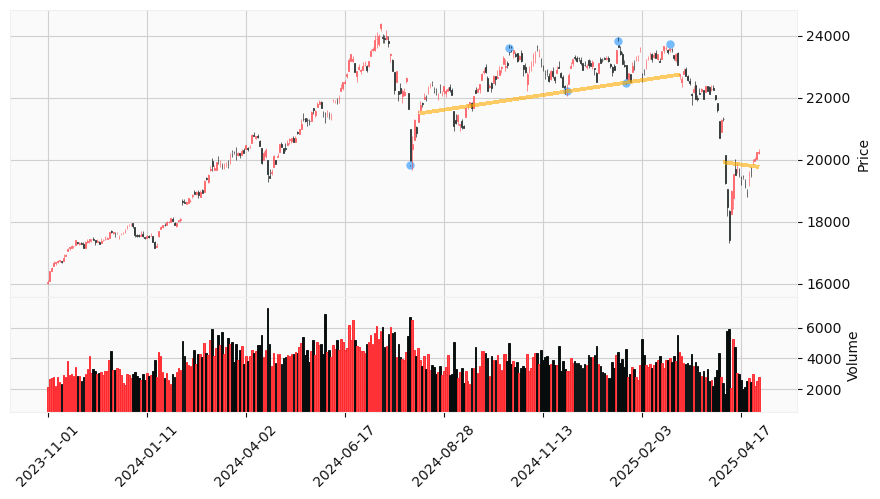

In [18]:
result = chart_pattern_recognition(range_prices)
chart_pattern_visualization(range_prices,result)

> 對照：ChatGPT問答

*你說*：價格型態  
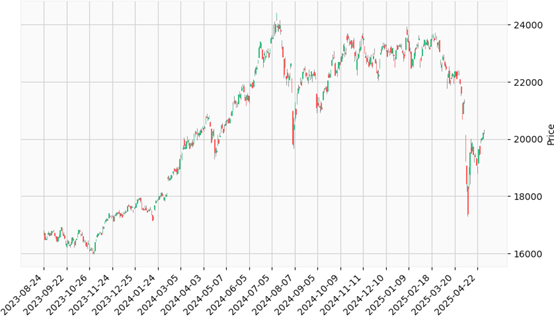  
  
**ChatGPT 說**：  
根據您提供的K線圖，該走勢圖從2023-08到2025-04呈現出以下主要價格型態：  
  
📈 頭肩頂（Head and Shoulders Top）  
•	左肩：2024-04 至 2024-06，價格緩步上漲  
•	頭部：2024-07中旬出現明顯高點（最高點）  
•	右肩：2024-09至2024-11間，反彈但未超過頭部高點  
•	頸線：約略連接2024-06與2024-10的低點  
•	跌破頸線：發生在2025年初，確認型態完成並出現明顯下跌  
  
輸出結果（JSON格式）：  
```
{
  "type": "頭肩頂",
  "start": "2024-04-01",
  "end": "2025-01-10"
}
```
  
*你說*：畫出頸線  
  
**ChatGPT 說**：  
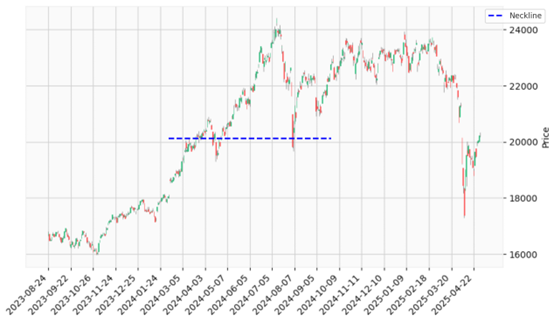  
已成功繪製出「頭肩頂」型態的頸線（藍色虛線），橫跨大約2024年6月至10月間的低點位置。這條頸線是該型態的關鍵支撐線，一旦跌破，通常會引發較大的下跌趨勢。  
  
*你說*：進一步分析近期走勢  
  
**ChatGPT 說**：  
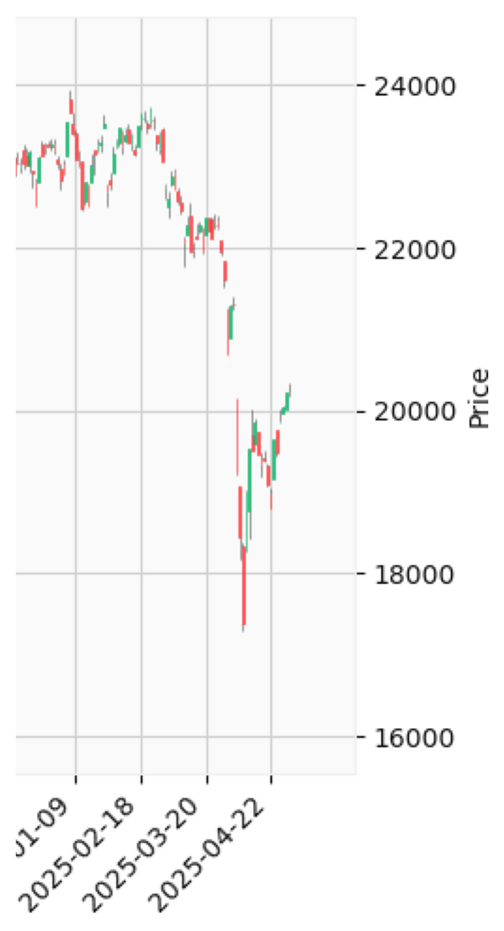  
根據近期走勢（約2025年初至4月底）的放大分析，可觀察到以下特徵：  
  
📉 近期走勢分析（2025年初以後）  
•	急跌段：2025年1月中旬起，股價快速由約22,000點下跌至低於18,000點，呈現明顯的恐慌性賣壓。  
•	V型反轉：2025年3月中旬見到低點後迅速反彈，形成典型「V型反轉」結構。  
•	反彈階段：至2025年4月底，價格已反彈至約20,000點附近，短期多頭動能增強，但尚未突破前高。  
  
📊 初步判斷型態：  
```
{
  "type": "V型反轉",
  "start": "2025-01-15",
  "end": "2025-04-30"
}
```